# Laboratorio: Redes Neuronales Convolucionales
## Dataset: Fashion-MNIST
**Objetivo:** Comparar un modelo baseline (sin convoluciones) contra una CNN 
diseñada desde cero, y explorar el efecto de distintas decisiones arquitectónicas.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Librerias listas.")

TensorFlow: 2.21.0
NumPy: 2.4.6
Librerias listas.


In [6]:
# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(" Forma de los datos ")
print(f"  Entrenamiento : {x_train.shape}")
print(f"  Prueba        : {x_test.shape}")
print(f"  Tipo de dato  : {x_train.dtype}")
print(f"  Rango valores : {x_train.min()} – {x_train.max()}")

 Forma de los datos 
  Entrenamiento : (60000, 28, 28)
  Prueba        : (10000, 28, 28)
  Tipo de dato  : uint8
  Rango valores : 0 – 255


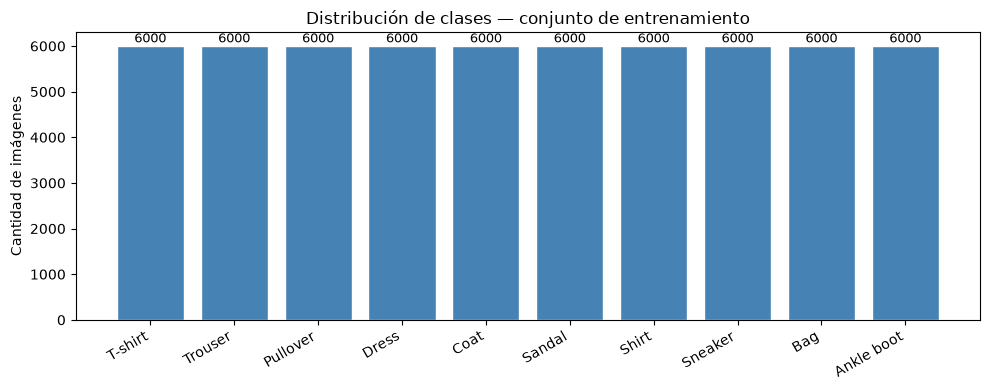

In [7]:
# Distribución de clases
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, counts, color='steelblue', edgecolor='white')
plt.title('Distribución de clases — conjunto de entrenamiento')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

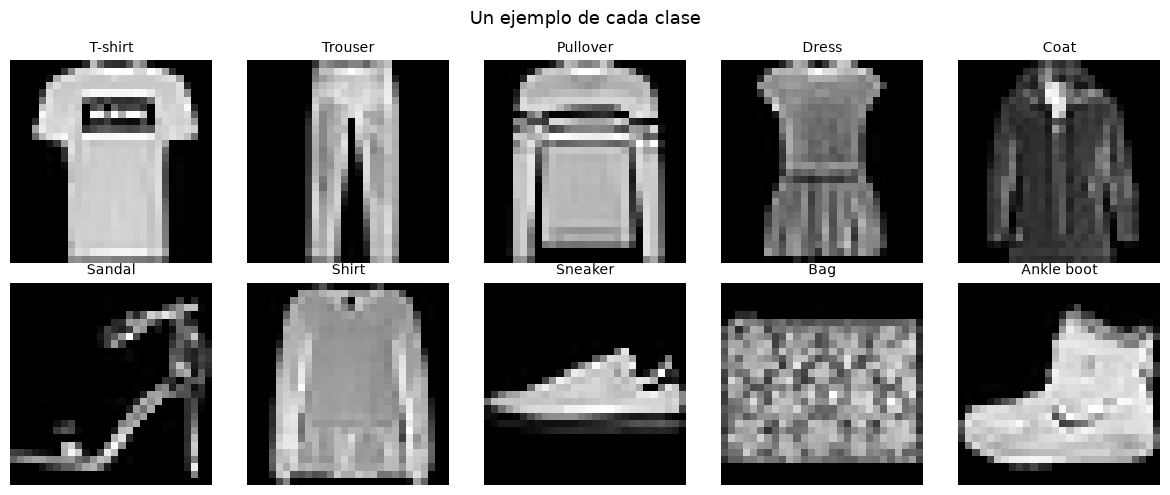

In [8]:
# Visualizar ejemplos por clase
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(x_train[idx], cmap='gray')
    axes[i].set_title(class_names[i], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Un ejemplo de cada clase', fontsize=13)
plt.tight_layout()
plt.show()

## Observaciones del EDA

- **Tamaño:** 70,000 imágenes en total (60,000 train / 10,000 test)
- **Dimensiones:** 28×28 píxeles, escala de grises (1 canal)
- **Clases:** 10, perfectamente balanceadas (6,000 por clase)
- **Rango de valores:** 0–255 → se normalizará a 0–1
- **Justificación para CNN:** Las imágenes tienen estructura espacial local 
  (bordes de prendas, texturas, siluetas) que las capas convolucionales 
  pueden capturar mediante filtros. Una red completamente conectada ignoraría 
  esta estructura espacial.

In [9]:
# Normalización y preparación
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Para la CNN añadimos dimensión de canal: (28,28) → (28,28,1)
x_train_cnn = x_train_norm[..., np.newaxis]
x_test_cnn  = x_test_norm[..., np.newaxis]

print(f"Datos para baseline : {x_train_norm.shape}  rango [{x_train_norm.min():.1f} – {x_train_norm.max():.1f}]")
print(f"Datos para CNN      : {x_train_cnn.shape}  rango [{x_train_cnn.min():.1f} – {x_train_cnn.max():.1f}]")
print("Preprocesamiento completo.")

Datos para baseline : (60000, 28, 28)  rango [0.0 – 1.0]
Datos para CNN      : (60000, 28, 28, 1)  rango [0.0 – 1.0]
Preprocesamiento completo.
